---
# Les métriques de qualité en classification
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "../images/metriques-classification.png"  width="500" />
    <div>
    <font size="1.5">Image Source: Medium - Muddapu Krishna Vamsee</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons voir les métriques de qualité/performances les plus utilisées en classification. 

## Table des matières
1. Introduction
2. Préparation et classification des données
3. L'interprétation des erreurs de classification
    1. Les types d'erreurs de classification
    2. Importances inégales des erreurs de classification
4. La matrice de confusion
5. Les métriques de classification
    1. L'exactitude (*accuracy*)
    2. La précision, le rappel, la sensibilité, la spécificité et la mesure F1
6. Les métriques globales de classification
    1. La courbe ROC (*Receiver Operator Characteristic*)
    2. La courbe Précision-Rappel
    3. Quelle métrique globale choisir pour sélectionner un classificateur parmi plusieurs?

#### Importation des librairies utilisées.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sklearn
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set(color_codes=True)


seed = 42
np.random.seed(seed)

## Introduction

Dans ce module, nous allons discuter de plusieurs métriques utilisées pour évaluer la qualité d'une classification.
Elles sont également utilisées pour comparer divers modèles entre eux afin de choisir le meilleur. 

Pour ce faire, nous allons utiliser le jeu de données IRIS qui contient les mesurations de trois espèces
d'iris; Versicolor, Virginica et Setosa. La figure suivante montre une exemple de chaque espèce ainsi que les
mensurations contenues dans le jeu de données (longeurs et largeurs des pétales et des sépales). Ce jeu de données
est très utilisé en apprentissage automatique et en statistiques lorsqu'il est question de classification.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/iris-flowers.jpeg"  width="500" />
    <div>
    <font size="0.5">Image Source: https://www.ubuntupit.com/best-machine-learning-datasets-for-practicing-applied-ml/</font>
    </div>
</div>

Nous allons classifier les iris du jeu de données en utilisant la [régression logistique](https://fr.wikipedia.org/wiki/R%C3%A9gression_logistique). Les résultats de
classification seront ensuite utilisés pour calculer les différentes métriques.

## Préparation et classification des données

In [2]:
# Lecture des données
iris = datasets.load_iris()

# Séparation des données
X = iris.data
y = iris.target

# Noms des espèces d'iris
noms = iris.target_names

n_classes = noms.shape[0]

Génération des ensembles d'entraînement ($80~\%$ des données) et de test ($20~\%$ restants).
On utilise un **échantillonnage stratifié** afin de respecter la distribution des espèces d'iris dans chaque ensemble. 
On ne normalise pas les données dans ce qui suit puisqu'elles sont toutes du même ordre de grandeur.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)

In [4]:
# Entraînement du classificateur avec les données d'entraînement
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Prédictions des espèces d'iris pour l'ensemble de test
y_pred = clf.predict(X_test)

## L'interprétation des erreurs de classification

Dans ce qui suit, nous allons présenter les diverses métriques, puis les utiliser avec les
valeurs prédites $y_{\text{pred}}$ et les vraies valeurs $y_{\text{test}}$.

### Les types d'erreurs de classification

Prenons le cas le plus simple où l'on fait une classification selon deux classes. En général, on observe
que plusieurs prédictions sont correctes et d'autres non. Dans ce cas, il y a quatre résultats possibles.
Pour simplifier l'écriture, on va utiliser les classes $\{\text{Négatif}, \text{Positif}\}$. 

On se sert de la notation suivante DE (pour Diagnostic-Estimation) où E indique le résultat estimé $\{\text{Négatif}, \text{Positif}\}$ et D indique le diagnostic après vérification $\{\text{Vrai}, \text{Faux}\}$.

Les quatres résultats possibles sont:

- Bonnes prédictions:
    - vrai positif (VP): prédiction de la classe positive **et** observation de la classe positive,
    - vrai négatif (VN): prédiction de la classe négative **et** observation de la classe négative.


- Mauvaises prédictions
    - faux positif (FP): prédiction de la classe positive **mais** observation de la classe négative,
    - faux négatif (FN): prédiction de la classe négative **mais** observation de la classe positive.

### Importances inégales des erreurs de classification

L'importance de chaque résultat dépend de la situation où un test (c.-à-d. une classification) est requis.
Prenons le cas d'un test de dépistage du cancer chez un patient. Il y a quatre éventualités
possibles. Le pire diagnostic est un faux négatif. Le patient, soulagé qu'on n'ait rien trouvé, retourne chez lui.
Malheureusement, il devra revenir plus tard lorsque son cancer se sera aggravé.

- Bonnes prédictions:
    - vrai positif (VP): le patient a le cancer (après vérification) et il est traité immédiatement!
    - vrai négatif (VN): le patient n'a pas le cancer.
- Mauvaises prédictions:
    - faux positif (FP): fausse alarme. Le patient n'a pas le cancer (après vérification),
    - faux négatif (FN): le patient a un cancer non détecté qui risque de s'empirer...

Affichons les nombres de bonnes et mauvaises prédictions pour chaque espèce d'iris. Notons qu'il y a 30 fleurs de chaque espèce. On a donc $VP+VN+FP+FN=30$ pour chaque espèce.

In [5]:
rows = []

for i, nom in enumerate(noms):
    tn, fp, fn, tp = confusion_matrix(y_test == i, y_pred == i).ravel()
    rows.append([nom, tp, tn, fp, fn])

df_conf = pd.DataFrame(rows, columns=["Classe", "VP", "VN", "FP", "FN"])
df_conf


,Classe,VP,VN,FP,FN
0,setosa,10,20,0,0
1,versicolor,9,20,0,1
2,virginica,10,19,1,0


## La matrice de confusion

La matrice de confusion est un outil précieux pour détecter et interpréter les erreurs. Elle permet de visualiser facilement les résultats de la classification. L'analyse des erreurs permet de déterminer quelles nouvelles observations sont nécessaires pour améliorer les performances d'un classificateur.

Affichons la matrice de confusion combinant les 3 classes d'iris.

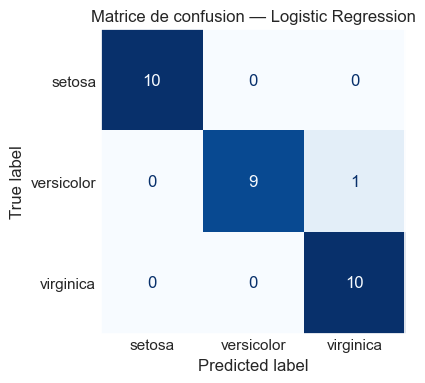

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=noms)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title("Matrice de confusion — Logistic Regression")
ax.grid(False)
ax.tick_params(axis="both", which="both", length=0)

plt.tight_layout()
plt.show()

Les prédictions correctes se situent le long de la diagonale principale, tandis que les prédictions erronées sont toutes situées hors de celle-ci.

Les Setosa et les Virginica ont été correctement classées ; aucune n'a été confondue avec une autre espèce.
En revanche, on voit qu'une Versicolor a été confondue avec une Virginica.

> À noter que les matrices de confusion sont rarement symétriques!

On pourrait améliorer la classification en ajoutant de nouvelles images de Virginica et de Versicolor à la base de données. Le classificateur apprendrait ainsi à mieux les différencier. Cette méthode a fait ses preuves.


## Les métriques de classification

### L'exactitude (*accuracy*)

C'est la métrique la plus intuitive de toutes. Elle représente la proportion de prédictions correctes (à la fois vraies
positives et vraies négatives) parmi l'ensemble des prédictions.

Dans le cas d'une classification selon deux classes, on la calcule comme suit

$$\text{Exactitude} = \dfrac{\text{VP} + \text{VN}}{\text{VP} + \text{VN} + \text{FP} + \text{FN}}.$$

Dans le cas plus général d'une classification multiclasses, le calcul utilise la matrice de
confusion $M$ associée comme suit

$$\begin{align}
\text{Exactitude} &= \dfrac{\text{Somme des valeurs le long de la diagonale principale}}{\text{Somme de toutes les valeurs}} \\
  &= \dfrac{\sum\limits_{i=1}^N M_{i,i}}{\sum_{i=1}^{N}\sum_{j=1}^{N} M_{i,j}}.
\end{align}$$

L'exactitude est toutefois sensible au débalancement des classes lors d'une classification. Supposons que l'on
veuille classifier des images de chats et de chiens et que l'on dispose d'un  jeu de données
d'entraînement contenant $99~\%$ d'images chats et seulement $1~\%$ d'images de chiens. Si on utilise un classificateur
stupide prédisant toujours la classe la plus populeuse alors il prédira toujours que des chats. Il ne se trompera
qu'avec les images de chiens, soit $1~\%$ du temps. Un tel classificateur aura une exactitude de $99~\%$ même s'il
ne fait aucune classification! C'est la principale faiblesse de la métrique d'exactitude.

Il est correct d'utiliser la métrique d'exactitude dans les situations où toutes les classes sont balancées.

### La précision, le rappel, la sensibilité, la spécificité et la mesure F1

Ces nouvelles métriques ajoutent un niveau de subtilité dans l'évaluation des performances d'un classificateur.

Supposons que vous avez développé un test de dépistage pour une maladie particulière. Votre test est sous évaluation par les
instances de la santé. Il est appliqué à des sujets sains et des sujets malades pour lesquels l'état de santé est
parfaitement connu.

La figure suivante montre les résultats.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/precision-recall-and-others.png" width="400" />
    <div>
    <font size="0.5">Image Source: https://fr.wikipedia.org/wiki/Précision_et_rappel/</font>
    </div>
</div>

La colonne de gauche (éléments pertinents) correspond aux sujets malades et celles de droite aux sujets sains.
Dans la colonne de gauche, les vrais positifs sont des cas réels dépistés, les faux négatifs sont des cas réels ignorés.

#### La précision
La précision est la proportion des tests positifs qui correspondent réellement à des sujets malades.

$$\text{Précision} = \dfrac {\text{VP}}{\text{VP} + \text{FP}}$$
Si votre test identifie 100 sujets positifs alors qu'en réalité, seuls 60 d'entre eux le sont vraiment alors
votre test a une précision de $60~\%$. Il génère également $40~\%$ de fausses alarmes!

#### Le rappel (*recall*) ou la sensibilité

Le rappel est la proportion des sujets malades détectés par votre test et qui le sont réellement.

$$\text{Rappel} = \dfrac{\text{VP}}{\text{VP} + \text{FN}}$$
Supposons qu'on vous demande de tester une cohorte de 100 sujets malades et que le test n'en détecte que
70 parmi eux; il a alors un rappel de $70~\%$.

#### La spécificité

Ce que le rappel mesure pour les sujets malades, la spécificité le mesure pour les sujets sains. Ainsi,
la spécificité est la proportion des sujets sains détectés par votre test et qui le sont réellement.

$$\text{Spécificité} = \dfrac{\text{VN}}{\text{VN} + \text{FP}}$$
Supposons qu'on vous demande de tester une cohorte de 100 sujets sains et que le test n'en détecte
que 70 parmi eux; il a alors une spécificité de $70~\%$.

#### La mesure F1 (*F1-Score*)

La précision et le rappel donnent de l'information sur les performances d'un test lorsqu'il détecte la classe d'intérêt.
Dans la pratique, il arrive que l'on doive choisir l'une ou l'autre de ces métriques alors que les deux sont pertinentes.
Laquelle choisir?

La métrique F1 offre un compromis entre les deux en calculant leur moyenne harmonique selon

$$F_{1}=2\cdot \dfrac {(\text{Précision}\cdot \text{Rappel})}{(\text{Précision}+\text{Rappel})}$$

Le rapport de classification (`classification_report`) est très utile pour présenter les statistiques d'exactitude, de précision, de rappel et de F1. Calculons-le pour notre problème.

In [7]:
print(classification_report(y_test, y_pred, target_names=noms))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Les résultats en précision montrent que le classificateur performe mieux avec les fleurs de type Setosa et Versicolor; $100~\%$ des prédictions de ces iris étaient correctes. Les résultats en rappel montrent que le classificateur performe mieux avec les fleurs de type Setosa et Virginica; $100~\%$ de ces iris ont été identifiés.

On observe une exactitude (`accuracy`) de $97~\%$, ce qui est très bon.

## Les métriques globales de classification

Pour simplifier la discussion, nous allons faire l'hypothèse, dans ce qui suit, que le problème de classification n'implique que deux classes. En plus d'indiquer la classe gagnante, plusieurs classificateurs peuvent aussi donner la probabilité de chaque classe. Par défaut, la classe gagnante est celle pour laquelle la probabilité est supérieure à un seuil $\tau>50~\%$. Toutefois, cette valeur n'est pas toujours la meilleure à utiliser.

Prenons l'exemple d'une girafe qui veut déterminer si l'animal qu'elle voit au loin est bien un lion. Si $P(\text{lion})\le 10~\%$, la girafe pense qu'elle voit probablement un autre type d'animal et qu'elle n'est pas en danger. Si $P(\text{lion})\gt 10~\%$, elle pense qu'elle est en danger et doit s'enfuir. Ainsi, la girafe n'a pas besoin d'attendre que le lion soit à 20 mètres d'elle
pour avoir $P(\text{lion})\gt 50~\%$ pour s'enfuir. À ce moment-là, il serait déjà trop tard!

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/giraffes.jpeg" width="400" />
    <div>
    <font size="0.5">Image Source: https://cdn.pixabay.com/photo/2017/10/30/21/53/giraffes-2903626_960_720.jpg</font>
    </div>
</div>

Les valeurs des métriques précédentes sont fortement dépendantes de la valeur de seuil $\tau$ utilisée dans chaque cas. Il est préférable d'utiliser une approche plus globale où les performances d'un classificateur sont évaluées en tenant compte de toutes les valeurs possibles de seuil $\tau$. Nous allons discuter de deux nouvelles métriques **globales**
couramment utilisées pour comparer entre elles les performances de multiples classificateurs. Chacune consiste à mesurer l'aire sous la courbe (*area under curve* ou *AUC*) combinant deux des métriques précédentes entre lesquelles il est souvent difficile de choisir.

### La courbe ROC (*Receiver Operator Characteristic*)

La fonction d’efficacité du récepteur montre comment varie le taux de vrais positifs
(TVP) en fonction du taux de faux positifs (TFP). Ces éléments correspondent aux équations suivantes:

$$
\begin{align}
\text{TVP} &= \dfrac {\text{VP}}{\text{VP} + \text{FN}}\\
\text{TFP} &= \dfrac {\text{FP}}{\text{FP} + \text{VN}}.
\end{align}
$$

La figure ci-dessous montre les courbes ROC de différents classificateurs. Le classificateur idéal est celui qui ne commet aucune erreur, c'est-à-dire que le nombre de faux négatifs (FN) et de faux positifs (FP) est nul, ce qui équivaut à dire que le nombre de vrais positifs (TFP) et de vrais négatifs (FPR) est nul, et que le nombre de vrais positifs (TVP) et de vrais négatifs (TPR) est égal à 1. Cela correspond à la position du point bleu en haut à gauche. Plus la courbe ROC d'un classificateur se rapproche de ce point, meilleures sont ses performances. Cela se traduit également par une plus grande aire sous la courbe. Lorsqu'il faut choisir entre plusieurs classificateurs, c'est celui qui a la plus grande aire sous la courbe qui doit être sélectionné.


> À noter que la ligne en pointillés rouges correspond à un classificateur générant un résultat parfaitement aléatoire, soit 50 % de classe 0 et 50 % de classe 1.

Pour un classificateur donné, la courbe est générée comme suit : On fait varier le seuil de détection entre 0 % et 100 %. Pour chaque valeur de seuil, on classe les données. On détermine ensuite les bonnes et les mauvaises classifications, ce qui permet de calculer les valeurs de TP, FP, TN et FN. On calcule ensuite les valeurs de TFP et de TVP. On affiche ensuite le point (TFP, TVP) correspondant dans le plan, puis on répète l'opération pour toutes les valeurs de seuil de probabilité. À la fin, on observe la courbe ROC.


<p>&nbsp;</p>
<div align="center">
    <img src= "./images/roc-curve.png" width="400" />
    <div>
    <font size="0.5">Image Source: https://en.wikipedia.org/wiki/Receiver_operating_characteristic</font>
    </div>
</div>
<p>&nbsp;</p>

### La courbe Précision-Rappel

Cette courbe est similaire à la précédente, sauf qu'elle utilise la précision et le rappel plutôt
que les taux de vrais et de faux positifs.

La figure suivante montre comment varient conjointement le rappel et la précision. Le code
de couleur indique la valeur de seuil de probabilité $\tau \in [0,1]$ correspondante à
chaque couple de valeurs (rappel, précision).

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/pr-curve.png" width="500" />
    <div>
    <font size="0.5">Image Source: https://stackoverflow.com/questions/25020788/in-r-calculate-area-under-precision-recall-curve-aupr</font>
    </div>
</div>
<p>&nbsp;</p>

Le classificateur idéal est celui qui ne commet aucune erreur, c'est-à-dire que le nombre de faux négatifs (FN) et de faux positifs (FP) est nul, et que le rappel (Rappel) et la précision (Précision) sont donc égaux à 1.
Cela correspond au coin supérieur droit. Plus la courbe « Précision-Rappel » d'un classificateur se rapproche de ce point, meilleures sont ses performances. Cela se traduit, à nouveau, par une plus grande aire sous la courbe. Comme pour la courbe ROC, si l'on doit choisir entre plusieurs classificateurs, il faut sélectionner celui dont l'aire sous la courbe Précision-Rappel est la plus grande.

### Quelle métrique globale choisir pour comparer plusieurs classificateurs ?
Cela dépend principalement du déséquilibre des classes :

1. Jeux de données équilibrés
    1. Les classes ont des proportions similaires.
    2. L’aire sous la courbe ROC (AUC‑ROC) est une bonne métrique globale.
    3. Elle mesure la capacité du modèle à séparer les classes, indépendamment du seuil.
2. Jeux de données déséquilibrés
    1. La classe positive est rare (fraude, cancer, défaut, panne…).
    2. L’aire sous la courbe Précision–Rappel (AUC‑PR) est préférable.
    3. Elle met l’accent sur la performance du modèle sur la classe minoritaire, ce que la ROC masque partiellement.
